In [36]:
from langgraph.store.memory import InMemoryStore

In [37]:
store=InMemoryStore()           #InmemoryStore is one implementation of Memory store,(uses RAM)

In [38]:
# In memory store, we use namespace(~Folder in Google Drive)
namespace=("user","u1")

# Creating Memories

In [39]:
store.put(namespace,"1",{"name":"Nisarg"})
store.put(namespace,"2",{"Data":"I like pastaaa"})

In [40]:
namespace2=("user","u2") #The namespace can be any length

In [41]:
store.put(namespace2,"1",{"name":"Rahul"})
store.put(namespace2,"2",{"Data":"I like pizzaaaaa"})

# Retrieve

In [42]:
item=store.get(namespace,"2")
item

Item(namespace=['user', 'u1'], key='2', value={'Data': 'I like pastaaa'}, created_at='2026-06-10T12:27:36.962427+00:00', updated_at='2026-06-10T12:27:36.962430+00:00')

In [43]:
for items in store.search(namespace):
    print(items.value)

{'name': 'Nisarg'}
{'Data': 'I like pastaaa'}


# Problems with above retrieval method
    - The 1st approach used when we know speciific key, the second when we wanna fetch all.
    - But what if we rquire a subset of all memories
    - shouldn't fetch all and scan from it here :)
    # So we require Semantic Search (fetch only relevant memories)

In [64]:
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer
load_dotenv()

True

# What happens if you don't specify the model?

    - When you do:

        - embedding = HuggingFaceEmbeddings()

        - LangChain loads a default model.

# The problem is that:
    The default model can change between versions.
    You don't know its embedding dimension beforehand.
    Your code becomes less reproducible.

In [71]:
embedding=HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")

In [72]:
store=InMemoryStore(index={'embed':embedding,'dims':384})

In [73]:
namespace=("users","u1")

In [74]:
store.put(namespace, "1", {"data": "User prefers concise answers over long explanations"})
store.put(namespace, "2", {"data": "User likes examples in Python"})
store.put(namespace, "3", {"data": "User usually works late at night"})
store.put(namespace, "4", {"data": "User prefers dark mode in applications"})
store.put(namespace, "5", {"data": "User is learning machine learning"})
store.put(namespace, "6", {"data": "User dislikes overly theoretical explanations"})
store.put(namespace, "7", {"data": "User prefers step-by-step reasoning"})
store.put(namespace, "8", {"data": "User is based in India"})
store.put(namespace, "9", {"data": "User likes real-world analogies"})
store.put(namespace, "10", {"data": "User prefers bullet points over paragraphs"})

In [75]:
response=store.search(namespace,query="What is user currently Learning",limit=3)
for data in response:
    print(data.value)

{'data': 'User is learning machine learning'}
{'data': 'User likes real-world analogies'}
{'data': 'User likes examples in Python'}


In [76]:
for data in store.search(namespace,query="What are user's preference",limit=4):
    print(data.value)

{'data': 'User likes examples in Python'}
{'data': 'User prefers dark mode in applications'}
{'data': 'User likes real-world analogies'}
{'data': 'User prefers step-by-step reasoning'}


# Connecting Langgraph with Memory store
    - BaseStore is the abstract base class that defines the interface for long-term memory, while InMemoryStore is a specific, lightweight implementation of that interface. 

In [80]:
from langgraph.graph import StateGraph,START,END,MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage,BaseMessage,SystemMessage
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langgraph.graph.message import add_messages
from typing import TypedDict,Annotated,List
from dotenv import load_dotenv
from langchain_core.runnables import RunnableConfig
import os
load_dotenv()

True

In [83]:
# ----------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------
store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Nisarg"})
store.put(user_details, "profile_2", {"data": "Profession: likes vlogging and upload YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [84]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}"""

In [85]:
llm=ChatGroq(model='llama-3.1-8b-instant')

In [86]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

In [87]:
config={"configurable":{"user_id":"u1"}}

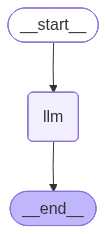

In [88]:
graph=StateGraph(MessagesState)
graph.add_node("llm",chat_node)
graph.add_edge(START,"llm")
graph.add_edge("llm",END)
app=graph.compile(store=store)
app

In [89]:
res=app.invoke({"messages":[HumanMessage(content="Explain in detail about Langgraph framework")]},config=config)
print(res['messages'][-1].content)

Since your project is built with Python and involves building MCP servers, I'll provide you with a detailed overview of the Langgraph framework.

Langgraph is a Python-based framework for building graph algorithms and applications. It's designed to provide a simple and efficient way to work with graphs, making it an excellent choice for your MCP server project.

Key Features of Langgraph:

1. **Graph Data Structure**: Langgraph provides a robust graph data structure, allowing you to create and manipulate graphs with ease. You can represent graphs as dictionaries, which makes it easy to work with.
2. **Graph Algorithms**: Langgraph includes a wide range of graph algorithms, such as Dijkstra's algorithm, Bellman-Ford algorithm, Floyd-Warshall algorithm, and more. These algorithms can be used to solve various graph-related problems.
3. **Graph Traversal**: Langgraph provides several graph traversal algorithms, including Depth-First Search (DFS) and Breadth-First Search (BFS). You can use 

In [90]:
res=app.invoke({"messages":[HumanMessage(content="What is my name?")]},config=config)
print(res['messages'][-1].content)

Your name is Nisarg. How are you doing today? 

Would you like to know more about your MCP server project, or perhaps get some help with a vlogging-related task?


# Observe:
    - The above mesg is based on what additional context wwe sent by retreiving from in memory store

# Memory Injection to memory store

In [117]:
from langgraph.graph import StateGraph,START,END,MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage,BaseMessage,SystemMessage
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langgraph.graph.message import add_messages
from typing import TypedDict,Annotated,List
from dotenv import load_dotenv
from langchain_core.runnables import RunnableConfig
from pydantic import BaseModel, Field
import os
import uuid
load_dotenv()

True

In [133]:
extractor_llm=ChatGroq(model='llama-3.1-8b-instant',temperature=0)

In [138]:
class state(TypedDict):
    message:Annotated[List[BaseMessage],add_messages]

In [120]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store")
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [155]:
def remember(state:state,config:RunnableConfig,store:BaseStore):
    user_id=config['configurable']['user_id']
    namespace=("user",user_id,"details")
    print("STATE:", state)

    msgs = state.get("message", [])
    print("MESSAGES:", msgs)

    if not msgs:
        print("No messages received!")
        return {}

    last_msg = msgs[-1].content
    sysprompt= SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            )
    res:MemoryDecision=memory_extractor.invoke([sysprompt, HumanMessage(content=last_msg)])
    if res.should_write:
        for msg in res.memories:
            print("Will have to store this yeah: ",msg)
            store.put(namespace,str(uuid.uuid4()),{"data":msg})
    return {"message":[AIMessage(content="Noted")]}

In [156]:
graph=StateGraph(state)
graph.add_node("store_node",remember)
graph.add_edge(START,"store_node")
graph.add_edge("store_node",END)

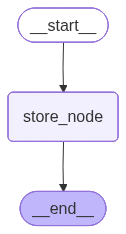

In [157]:
store=InMemoryStore()
app=graph.compile(store=store)
config={"configurable":{"user_id":"u1"}}
app

In [158]:
res=app.invoke({"message":[HumanMessage(content="Hi there, myself Nisarg")]},config=config)
print(res['message'][-1].content)

STATE: {'message': [HumanMessage(content='Hi there, myself Nisarg', additional_kwargs={}, response_metadata={}, id='1a5f71dd-5833-43b4-bcf7-e05be4163285')]}
MESSAGES: [HumanMessage(content='Hi there, myself Nisarg', additional_kwargs={}, response_metadata={}, id='1a5f71dd-5833-43b4-bcf7-e05be4163285')]
Will have to store this yeah:  My name is Nisarg
Noted


In [159]:
res=app.invoke({"message":[HumanMessage(content="Hi there, I like making vlogs and edit photos, besides I also like coding and debugging")]},config=config)
print(res['message'][-1].content)

STATE: {'message': [HumanMessage(content='Hi there, I like making vlogs and edit photos, besides I also like coding and debugging', additional_kwargs={}, response_metadata={}, id='85c8606d-72a0-4fca-841a-154863177314')]}
MESSAGES: [HumanMessage(content='Hi there, I like making vlogs and edit photos, besides I also like coding and debugging', additional_kwargs={}, response_metadata={}, id='85c8606d-72a0-4fca-841a-154863177314')]
Will have to store this yeah:  I like making vlogs
Will have to store this yeah:  I edit photos
Will have to store this yeah:  I like coding
Will have to store this yeah:  I like debugging
Noted


In [160]:
res=app.invoke({"message":[HumanMessage(content="I prefer selective association with others")]},config=config)
print(res['message'][-1].content)

STATE: {'message': [HumanMessage(content='I prefer selective association with others', additional_kwargs={}, response_metadata={}, id='e2b93fc5-2d49-4223-81e7-ad759d8c1ea4')]}
MESSAGES: [HumanMessage(content='I prefer selective association with others', additional_kwargs={}, response_metadata={}, id='e2b93fc5-2d49-4223-81e7-ad759d8c1ea4')]
Will have to store this yeah:  I prefer selective association with others
Noted


In [162]:
for items in store.search(("user","u1","details")):
    print(items.value['data'])

My name is Nisarg
I like making vlogs
I edit photos
I like coding
I like debugging
I prefer selective association with others


# Any Flaw?
    - Duplication of memory possible :(
# Solution:

In [167]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [168]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [169]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [170]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [190]:
def remember(state:state,config:RunnableConfig,store:BaseStore):
    user_id=config['configurable']['user_id']
    namespace=("user",user_id,"details")
    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    last_text = state["message"][-1].content

    # C) LLM extracts memories + marks new vs duplicate
    res: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )
    if res.should_write:
        for msg in res.memories:
            if msg.is_new:
                print("Will have to store this yeah!!: ",msg)
                store.put(namespace,str(uuid.uuid4()),{"data":msg})
    return {"message":[AIMessage(content="Noted")]}

In [191]:
graph=StateGraph(state)
graph.add_node("store_node",remember)
graph.add_edge(START,"store_node")
graph.add_edge("store_node",END)

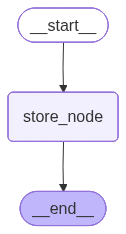

In [192]:
store=InMemoryStore()
app=graph.compile(store=store)
config={"configurable":{"user_id":"u1"}}
app

In [193]:
res=app.invoke({"message":[HumanMessage(content="Hi there, myself Nisarg")]},config=config)
print(res['message'][-1].content)

Will have to store this yeah!!:  text='My name is Nisarg' is_new=True
Noted


In [194]:
res=app.invoke({"message":[HumanMessage(content="Hi there I like vlogging")]},config=config)
print(res['message'][-1].content)

Will have to store this yeah!!:  text='I like vlogging' is_new=True
Noted


In [195]:
res=app.invoke({"message":[HumanMessage(content="Hi there I like vlogging")]},config=config)
print(res['message'][-1].content)

Noted


In [196]:
for items in store.search(("user","u1","details")):
    print(items.value['data'])

text='My name is Nisarg' is_new=True
text='I like vlogging' is_new=True
